# TESS End-to-End Smoke Test

This notebook is for **live manual validation** of the raw-TESS transit-fit path in `dataio.tess_photometry`.

What is already covered by automated tests:
- retrieval-ready constraint export
- `.tbl` export and parse round-trip
- CLI wiring from `--fit-tess-transit`
- propagation of `quality_bitmask` and `flux_column`

What is **not** covered by automated tests in this environment:
- live `lightkurve` download from MAST
- a real `mlexo` transit fit using your local environment and target choice

Use this notebook to validate the full live path interactively.

In [1]:
from pathlib import Path
import json
import os
import sys

os.environ.setdefault("JAX_PLATFORMS", "cpu")

_candidate_roots = [Path.cwd(), Path.cwd().parent]
for _root in _candidate_roots:
    if (_root / "pipeline").is_dir() and (_root / "config").is_dir():
        REPO_ROOT = _root.resolve()
        if str(REPO_ROOT) not in sys.path:
            sys.path.insert(0, str(REPO_ROOT))
        break
else:
    raise FileNotFoundError("Could not locate repo root containing pipeline/ and config/")

print(f"Repo root: {REPO_ROOT}")

import matplotlib.pyplot as plt
import numpy as np
import lightkurve as lk
from IPython.display import Markdown, display

import config
from dataio.tess_photometry import (
    TessTransitFitConfig,
    build_joint_tess_dataset,
    download_tess_lightcurves,
    fit_tess_transit_to_bandpass_constraint,
    serialize_tess_fit_summary,
)
from pipeline.retrieval import make_bandpass_constraints_from_tbl

plt.style.use("default")


Repo root: /Volumes/drive-2tb/code/atmo-retrieval


/opt/homebrew/Caskroom/miniconda/base/envs/retrieval/lib/python3.10/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/retrieval/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/homebrew/Caskroom/miniconda/base/envs/retrieval/lib/python3.10/site-packages/exojax/database/vald/api.py:29: FutureWarning: moldb module will be renenamed to adb in future.
  warnings.warn("moldb module will be renenamed to adb in future.", FutureWarning)


In [2]:
# Edit this cell for the target you want to validate.

PLANET = "KELT-20b"
EPHEMERIS = "Duck24"
TESS_TARGET = "KELT-20"

# Leave as None to use all available sectors jointly.
SECTORS = None

MISSION = "TESS"
AUTHOR = "SPOC"
EXPTIME_S = 120
QUALITY_BITMASK = "default"   # one of none/default/hard/hardest or an integer bitmask
FLUX_COLUMN = "pdcsap_flux"   # try "sap_flux" if you want to compare products

OBSERVABLE = "radius_ratio"   # or "transit_depth"
CONSTRAINT_NAME = "tess_transit"
PHOTON_WEIGHTED = False
WRITE_TBL = True

PLANET_SLUG = PLANET.lower().replace("-", "").replace(" ", "")
PHOT_MODE = "transmission"
PHOT_OUTPUT_DIR = REPO_ROOT / "input" / "phot" / PHOT_MODE / PLANET_SLUG
PHOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TBL_OUTPUT_PATH = PHOT_OUTPUT_DIR / f"{PLANET_SLUG}_tess_bandpass.tbl"

params = config.get_params(planet=PLANET, ephemeris=EPHEMERIS)
PERIOD_D = float(params["period"])
T0_BJD = float(params["epoch"])
T0_BTJD = T0_BJD - 2457000.0
TRANSIT_DURATION_D = float(params["duration"])
RADIUS_RATIO_GUESS = float(params["rp_rs"])
IMPACT_GUESS = float(params["b"])

fit_config = TessTransitFitConfig(
    target=TESS_TARGET,
    period_d=PERIOD_D,
    t0_btjd=T0_BTJD,
    transit_duration_d=TRANSIT_DURATION_D,
    radius_ratio_guess=RADIUS_RATIO_GUESS,
    impact_guess=IMPACT_GUESS,
    mission=MISSION,
    author=AUTHOR,
    exptime_s=EXPTIME_S,
    quality_bitmask=QUALITY_BITMASK,
    flux_column=FLUX_COLUMN,
    sectors=None if SECTORS is None else tuple(SECTORS),
    planet_name=PLANET,
    reference=EPHEMERIS,
    note="Notebook-generated TESS bandpass constraint",
)

display(Markdown("## Active fit configuration"))
print(json.dumps(
    {
        "planet": PLANET,
        "ephemeris": EPHEMERIS,
        "tess_target": TESS_TARGET,
        "sectors": SECTORS,
        "period_d": PERIOD_D,
        "t0_bjd": T0_BJD,
        "t0_btjd": T0_BTJD,
        "transit_duration_d": TRANSIT_DURATION_D,
        "radius_ratio_guess": RADIUS_RATIO_GUESS,
        "impact_guess": IMPACT_GUESS,
        "quality_bitmask": QUALITY_BITMASK,
        "flux_column": FLUX_COLUMN,
        "observable": OBSERVABLE,
        "tbl_output_path": str(TBL_OUTPUT_PATH),
    },
    indent=2,
))


## Active fit configuration

{
  "planet": "KELT-20b",
  "ephemeris": "Duck24",
  "tess_target": "KELT-20",
  "sectors": null,
  "period_d": 3.47410151,
  "t0_bjd": 2459757.811176,
  "t0_btjd": 2757.811176000163,
  "transit_duration_d": 0.147565,
  "radius_ratio_guess": 0.111,
  "impact_guess": 0.5,
  "quality_bitmask": "default",
  "flux_column": "pdcsap_flux",
  "observable": "radius_ratio",
  "tbl_output_path": "/Volumes/drive-2tb/code/atmo-retrieval/input/phot/transmission/kelt20b/kelt20b_tess_bandpass.tbl"
}


In [3]:
search_kwargs = {
    "mission": fit_config.mission,
    "author": fit_config.author,
    "exptime": fit_config.exptime_s,
}
if fit_config.sectors is not None:
    search_kwargs["sector"] = list(fit_config.sectors)

search = lk.search_lightcurve(fit_config.target, **search_kwargs)
display(Markdown("## Lightkurve search results"))
display(search)


## Lightkurve search results

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 14,2019,SPOC,120,69679391,0.0
1,TESS Sector 40,2021,SPOC,120,69679391,0.0
2,TESS Sector 41,2021,SPOC,120,69679391,0.0
3,TESS Sector 54,2022,SPOC,120,69679391,0.0
4,TESS Sector 74,2024,SPOC,120,69679391,0.0
5,TESS Sector 75,2024,SPOC,120,69679391,0.0
6,TESS Sector 81,2024,SPOC,120,69679391,0.0


## Downloaded light curves

Downloaded 7 light curves
{
  "sector_labels": [
    "TESS",
    "TESS",
    "TESS",
    "TESS",
    "TESS",
    "TESS",
    "TESS"
  ]
}


## Pre-fit joint dataset summary

{
  "n_sectors": 7,
  "sector_labels": [
    "TESS",
    "TESS",
    "TESS",
    "TESS",
    "TESS",
    "TESS",
    "TESS"
  ],
  "sector_counts": [
    833,
    1723,
    1727,
    1462,
    1724,
    1511,
    1294
  ],
  "n_cadences_total": 10274
}


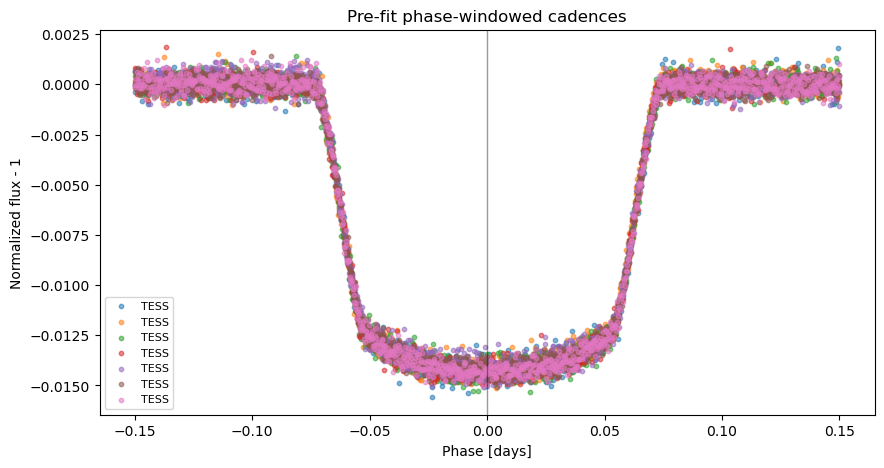

In [4]:
lc_collection = download_tess_lightcurves(fit_config)
sector_labels = [lc.meta.get("MISSION", f"sector_{idx + 1}") for idx, lc in enumerate(lc_collection)]

display(Markdown("## Downloaded light curves"))
print(f"Downloaded {len(lc_collection)} light curves")
print(json.dumps({"sector_labels": sector_labels}, indent=2))

dataset = build_joint_tess_dataset(
    lc_collection,
    period_d=fit_config.period_d,
    t0_btjd=fit_config.t0_btjd,
    transit_duration_d=fit_config.transit_duration_d,
    model_window_d=fit_config.model_window_d,
    flatten_window_length=fit_config.flatten_window_length,
    outlier_sigma=fit_config.outlier_sigma,
)

phase_days = ((dataset["time"] - fit_config.t0_btjd + 0.5 * fit_config.period_d) % fit_config.period_d) - 0.5 * fit_config.period_d

display(Markdown("## Pre-fit joint dataset summary"))
print(json.dumps(
    {
        "n_sectors": int(dataset["n_sectors"]),
        "sector_labels": list(dataset["sector_labels"]),
        "sector_counts": [int(x) for x in dataset["sector_counts"]],
        "n_cadences_total": int(dataset["time"].size),
    },
    indent=2,
))

fig, ax = plt.subplots(figsize=(10, 5))
for sector_id, label in enumerate(dataset["sector_labels"]):
    rows = dataset["sector_rows"][sector_id]
    ax.scatter(phase_days[rows], dataset["flux"][rows], s=10, alpha=0.55, label=label)
ax.axvline(0.0, color="black", lw=1.0, alpha=0.4)
ax.set_title("Pre-fit phase-windowed cadences")
ax.set_xlabel("Phase [days]")
ax.set_ylabel("Normalized flux - 1")
ax.legend(loc="best", fontsize=8)
plt.show()


In [5]:
result = fit_tess_transit_to_bandpass_constraint(
    fit_config,
    lc_collection=lc_collection,
    observable=OBSERVABLE,
    constraint_name=CONSTRAINT_NAME,
    photon_weighted=True if PHOTON_WEIGHTED else None,
    tbl_path=TBL_OUTPUT_PATH if WRITE_TBL else None,
)

summary = serialize_tess_fit_summary(result)

display(Markdown("## Retrieval-ready constraint"))
print(json.dumps(summary["constraint"], indent=2))

display(Markdown("## Selected posterior summaries"))
print(json.dumps(
    {
        key: summary["fit"]["summary_stats"][key]
        for key in ["r", "b", "duration", "transit_depth_percent"]
    },
    indent=2,
))

if WRITE_TBL:
    print(f"Wrote TESS bandpass table to: {TBL_OUTPUT_PATH}")


100%|██████████| 300/300 [1:19:38<00:00, 15.93s/it]


## Retrieval-ready constraint

{
  "name": "tess_transit",
  "mode": "transmission",
  "observable": "radius_ratio",
  "value": 0.11487564960506647,
  "sigma": 0.00022093174683505967
}


## Selected posterior summaries

{
  "r": {
    "lower": 0.1146547178582314,
    "median": 0.11487564960506647,
    "upper": 0.11507152411462246,
    "plus": 0.00019587450955599328,
    "minus": 0.00022093174683505967
  },
  "b": {
    "lower": 0.4914853745341076,
    "median": 0.49785322136894616,
    "upper": 0.5048382441675306,
    "plus": 0.006985022798584484,
    "minus": 0.006367846834838542
  },
  "duration": {
    "lower": 0.14733004584128243,
    "median": 0.14752421160660523,
    "upper": 0.1477108390412549,
    "plus": 0.00018662743464967213,
    "minus": 0.00019416576532280128
  },
  "transit_depth_percent": {
    "lower": 1.3145704327151995,
    "median": 1.3196414872186042,
    "upper": 1.3241455662092065,
    "plus": 0.004504078990602345,
    "minus": 0.005071054503404726
  }
}
Wrote TESS bandpass table to: /Volumes/drive-2tb/code/atmo-retrieval/input/phot/transmission/kelt20b/kelt20b_tess_bandpass.tbl


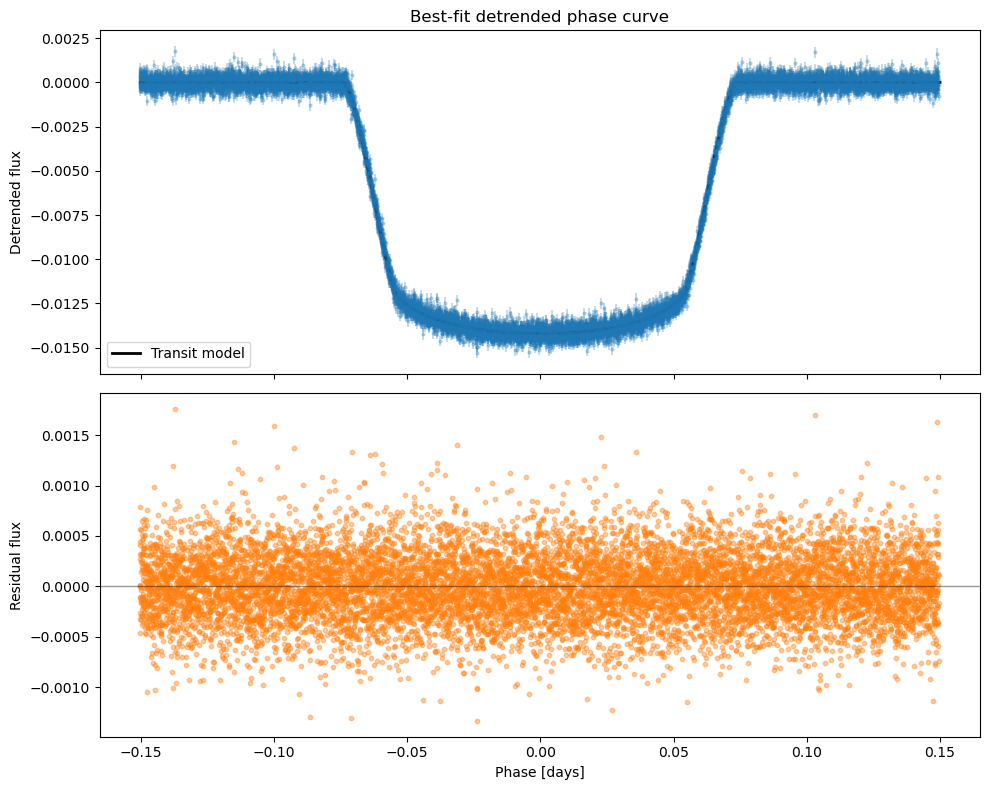

{
  "emcee_acceptance_fraction": 0.2836190476190476,
  "emcee_parallel": false,
  "emcee_worker_count": 1
}


In [10]:
best_fit = result.best_fit

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].errorbar(
    best_fit["phase_days"],
    best_fit["detrended_flux"],
    yerr=result.dataset["flux_err"],
    fmt=".",
    alpha=0.25,
    ms=4,
    color="tab:blue",
)
phase_order = np.argsort(best_fit["phase_grid"])
# phase_model_grid is already on the same zero-centered scale as detrended_flux.
axes[0].plot(
    best_fit["phase_grid"][phase_order],
    best_fit["phase_model_grid"][phase_order],
    color="black",
    lw=2,
    label="Transit model",
)
axes[0].set_ylabel("Detrended flux")
axes[0].set_title("Best-fit detrended phase curve")
axes[0].legend(loc="best")

axes[1].scatter(best_fit["phase_days"], best_fit["residual_flux"], s=10, alpha=0.4, color="tab:orange")
axes[1].axhline(0.0, color="black", lw=1.0, alpha=0.4)
axes[1].set_xlabel("Phase [days]")
axes[1].set_ylabel("Residual flux")

plt.tight_layout()
plt.show()

print(json.dumps(
    {
        "emcee_acceptance_fraction": summary["fit"]["emcee_acceptance_fraction"],
        "emcee_parallel": summary["fit"]["emcee_parallel"],
        "emcee_worker_count": summary["fit"]["emcee_worker_count"],
    },
    indent=2,
))


In [7]:
if WRITE_TBL:
    parsed_constraints = make_bandpass_constraints_from_tbl(TBL_OUTPUT_PATH)
    display(Markdown("## Constraint parsed back through retrieval helpers"))
    print(json.dumps(parsed_constraints, indent=2))
else:
    print("WRITE_TBL is False; no .tbl round-trip performed.")


## Constraint parsed back through retrieval helpers

[
  {
    "name": "lrs_kelt20b_tess_bandpass",
    "mode": "transmission",
    "observable": "transit_depth",
    "value": 0.0131964149,
    "sigma": 5.07594e-05
  }
]


## Next step into retrieval

If the live fit above looks good, the direct Python handoff is:

```python
from pipeline.retrieval import run_retrieval

run_retrieval(
    mode="transmission",
    epoch="20200101",
    data_format="timeseries",
    pt_profile=config.PT_PROFILE_DEFAULT,
    chemistry_model=config.CHEMISTRY_MODEL_DEFAULT,
    bandpass_constraints=[result.bandpass_constraint],
)
```

Or, if `WRITE_TBL = True`, use the generated file from `input/phot/transmission/<planet>/` with the existing CLI `--bandpass-tbl` path.